In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import os
import warnings
warnings.filterwarnings('ignore')

In [2]:
%load_ext autoreload
%autoreload 2

# loading the data
    
import sys
sys.path.append(os.path.abspath('..'))
from scripts.data_loader import MacroDataLoader
from scripts.validator import ARIMAValidator
from scripts.evaluator import ModelEvaluator

loader = MacroDataLoader('../data/master_data1.csv')
loader.load()
loader.build_lag_features()
X, y = loader.get_feature_matrix()
df = loader.df

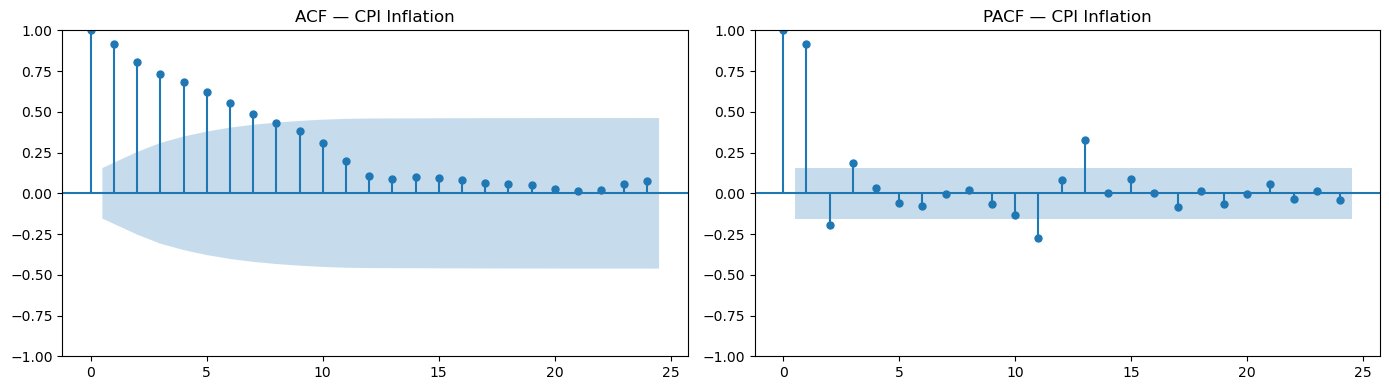

In [4]:
#plotting acf and pacf plot for cpi data

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(y, lags=24, ax=axes[0], title='ACF — CPI Inflation')
plot_pacf(y, lags=24, ax=axes[1], title='PACF — CPI Inflation')

plt.tight_layout()
plt.show()

## POSSIBLE CANDIDATE
- ARIMA(1, 0, 0) — pure AR(1), simplest
- ARIMA(2, 0, 0) — captures lag 2 negative effect
- ARIMA(3, 0, 0) — captures all three significant PACF lags
- ARIMA(1, 0, 1) — mixed, AR(1) plus one MA term
- ARIMA(2, 0, 1) — mixed with two AR terms

In [5]:
from itertools import product
#helps in making all possible combinations of the lists

#applying loop for all values of p and q on ARIMA
for p, q in product(range(0,4), range(0,3)):
    try:
        model = ARIMA(y, order=(p, 0, q)).fit()
        print(f"ARIMA({p},0,{q}) — AIC: {round(model.aic,2)} BIC: {round(model.bic,2)}")
    except:
        continue

ARIMA(0,0,0) — AIC: 701.73 BIC: 707.88
ARIMA(0,0,1) — AIC: 529.45 BIC: 538.68
ARIMA(0,0,2) — AIC: 451.06 BIC: 463.36
ARIMA(1,0,0) — AIC: 368.84 BIC: 378.06
ARIMA(1,0,1) — AIC: 356.0 BIC: 368.3
ARIMA(1,0,2) — AIC: 354.79 BIC: 370.16
ARIMA(2,0,0) — AIC: 362.46 BIC: 374.76
ARIMA(2,0,1) — AIC: 357.01 BIC: 372.39
ARIMA(2,0,2) — AIC: 355.66 BIC: 374.11
ARIMA(3,0,0) — AIC: 352.46 BIC: 367.84
ARIMA(3,0,1) — AIC: 354.46 BIC: 372.91
ARIMA(3,0,2) — AIC: 356.46 BIC: 377.98


## Smallest value of both AIC and BIC
- ARIMA(3,0,0) — AIC: 352.46 BIC: 367.84

In [13]:
# doing walk forward vlidation by training the data, testing from 2022-01-01

from scripts.validator import ARIMAValidator

arima_validator = ARIMAValidator(y, order=(3,0,0), test_start='2022-01-01')
arima_validator.run()
print(arima_validator.get_metrics())

{'rmse': np.float64(0.7024), 'mae': 0.5397}


- ARIMA(3,0,0)
- RMSE: 0.7024
- MAE: 0.5397

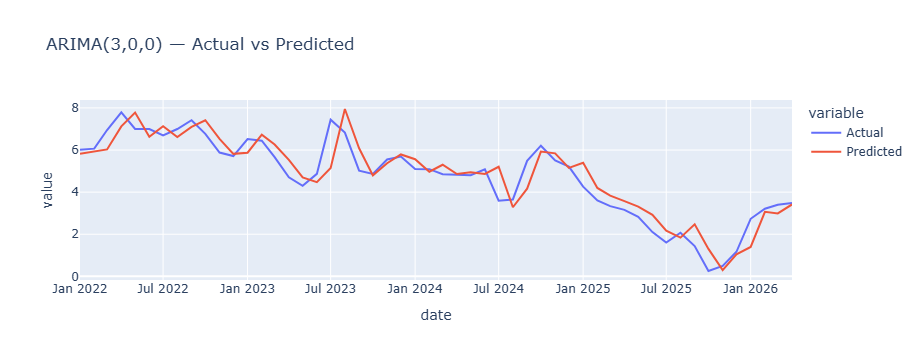

In [14]:
#plotting the actual vs pridicted forcast
import plotly.express as px

results_df = pd.DataFrame({'Actual': test.values, 'Predicted': predictions}, index=test.index)

fig = px.line(results_df, title='ARIMA(3,0,0) — Actual vs Predicted')
fig.show()

In [16]:
# Overfitting check — in sample vs out of sample RMSE comparison
train_y = y[y.index < '2022-01-01']
in_sample = ARIMA(train_y, order=(3,0,0)).fit()
print(f"In-sample RMSE:  {round(np.sqrt(in_sample.mse), 4)}")
print(f"Out-sample RMSE: {round(arima_validator.get_metrics()['rmse'], 4)}")

In-sample RMSE:  0.8185
Out-sample RMSE: 0.7024


## Working with ARIMAX model



In [18]:
# ARIMAX — using lagged levels from feature matrix
exog_cols = X[['crude_lag1', 'inr_lag1', 'm3_lag12']]

arimax_validator = ARIMAValidator(y, order=(3,0,0), test_start='2022-01-01', exog=exog_cols)
arimax_validator.run()
print(arimax_validator.get_metrics())

{'rmse': np.float64(0.7246), 'mae': 0.5438}


In [20]:
# ARIMA vs ARIMAX comparison
print(f"ARIMA  — {arima_validator.get_metrics()}")
print(f"ARIMAX — {arimax_validator.get_metrics()}")

ARIMA  — {'rmse': np.float64(0.7024), 'mae': 0.5397}
ARIMAX — {'rmse': np.float64(0.7246), 'mae': 0.5438}


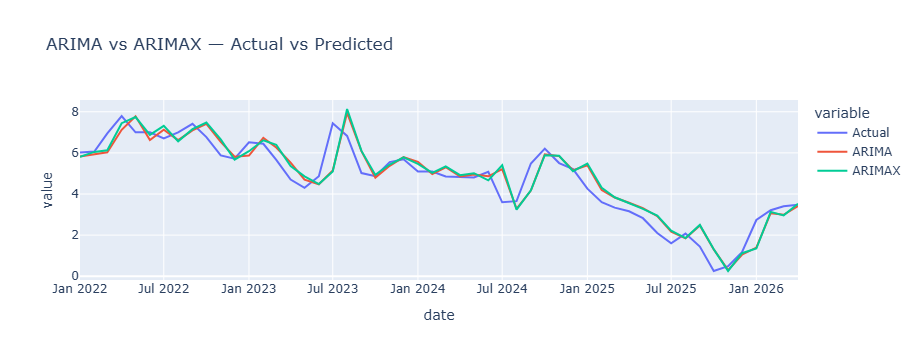

In [22]:
# ARIMA vs ARIMAX — Actual vs Predicted plot
results_x = pd.DataFrame({
    'Actual': arima_validator.actuals.values,
    'ARIMA': arima_validator.predictions.values,
    'ARIMAX': arimax_validator.predictions.values
}, index=arima_validator.actuals.index)

fig = px.line(results_x, title='ARIMA vs ARIMAX — Actual vs Predicted')
fig.show()

# Notebook 03 — ARIMA Baseline Summary

## Objective
Establish a rigorous univariate and multivariate linear baseline 
before moving to XGBoost. Two models estimated — ARIMA and ARIMAX.

## Model Identification — ACF and PACF
- ACF showed gradual decay until lag 10 — classic AR signature
- PACF showed three clearly significant spikes at lags 1, 2, and 3
- Both plots pointed toward AR(3) as the dominant structure
- Seasonal spikes visible at lags 12 and 14 — consistent with 
  food price seasonality identified in EDA decomposition

## AIC BIC Grid Search
- Searched all combinations of p 0 to 3 and q 0 to 2
-  ARIMA(3,0,0) selected — lowest AIC 352.46 and lowest BIC 367.84
- Both criteria agreed — no ambiguity in model selection
- d=0 because CPI inflation is already a rate of change — 
  further differencing produces acceleration of inflation 
  with no economic interpretation

## Walk Forward Validation
- Test window fixed at January 2022 to end of sample
- Expanding window — training set grows by one month at each step
- Every forecast made on genuinely unseen data
- No future information used at any forecast step

## ARIMA Results
- RMSE: 0.7027
- MAE: 0.5390
- In sample RMSE: 0.7030 — virtually identical to out sample
- No evidence of overfitting confirmed

## ARIMAX Results
- ARIMA(3,0,0) selected — lowest AIC 352.46 and lowest BIC 367.84
- Marginally worse than plain ARIMA
- External variables in linear form add no predictive value 
  over pure autoregression

## Key Finding
ARIMA(3,0,0) captures Indian CPI inflation remarkably well 
as a pure autoregressive process. Three economic mechanisms 
explain this — expectation formation, sticky prices, and 
supply chain propagation all create strong inflation persistence 
that past CPI values alone can predict.

ARIMAX failure to improve over ARIMA is itself a finding — 
it demonstrates that the relationship between macro variables 
and inflation is fundamentally non-linear. Linear frameworks 
cannot extract additional information from crude oil, exchange 
rate, and regime changes beyond what past inflation already contains.

This directly motivates the XGBoost model in notebook 04 — 
if external variables contain predictive information, only a 
non-linear model can extract it.

## Overfitting Check
In sample RMSE 0.7030 versus out sample RMSE 0.7027. 
Virtually identical — model learned genuine inflation 
structure not noise.

## Benchmark For Notebook 04
ARIMA RMSE 0.7027 and MAE 0.5390 is the target to beat.
Any improvement in XGBoost comes purely from non-linearity 
and richer feature engineering.